In [2]:
# Initialization
import pandas as pd 
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

class df_data():
  def __init__(self):
    self.gentoo = pd.read_csv('../data/gentoo_bugs_before_2012.csv')
    self.kde = pd.read_csv('../data/kde_bugs_before_2012.csv')
    self.suse = pd.read_csv('../data/suse_bugs_before_2012.csv')

data = df_data()

print(data.kde.columns)

def convert_date_column_to_year(df):
   df['creation_time'] = pd.DatetimeIndex(df['creation_time']).year
   return df

data.gentoo = convert_date_column_to_year(data.gentoo)
data.kde = convert_date_column_to_year(data.kde)
data.suse = convert_date_column_to_year(data.suse)

print(f"Gentoo Years: {data.gentoo['creation_time'].unique()}")
print(f"KDE Years:    {data.kde['creation_time'].unique()}")
print(f"Suse Years:   {data.suse['creation_time'].unique()}")


Index(['last_change_time', 'assigned_to', 'status', 'creation_time', 'creator',
       'severity', 'product', 'assigned_to_detail', 'id', 'priority',
       'component', 'creator_detail', 'resolution', 'dupe_of'],
      dtype='object')
Gentoo Years: [2002 2003 2004 2005 2006 2007 2008 2009 2010 2011]
KDE Years:    [1999 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011]
Suse Years:   [2004 2005 2001 2002 2003 1998 1997 1999 2006 2007 2008 2009 2010 2011]


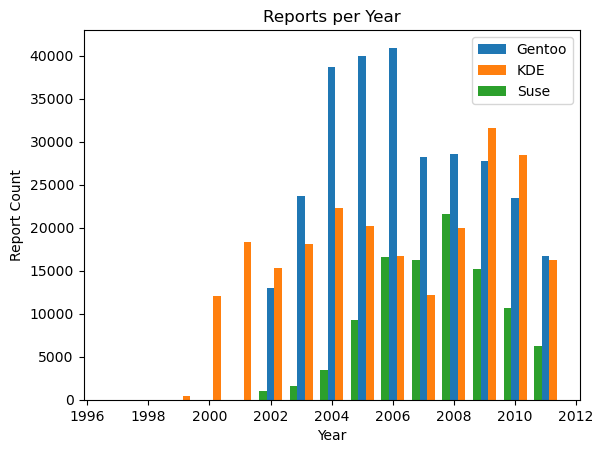

In [3]:
# Figure 1 Block
def get_tickets_per_year(df): 
    # Oldest ticket is 1997, latest is 2011   
    full_year_list = [d for d in df['creation_time']]
    year_list, counts = np.unique(full_year_list, return_counts=True)
  
    return year_list, counts

def create_tickets_per_year_plot(data):
  gentoo_years, gentoo_counts = get_tickets_per_year(data.gentoo)
  kde_years, kde_counts = get_tickets_per_year(data.kde)
  suse_years, suse_counts = get_tickets_per_year(data.suse)  
  
  fig, ax = plt.subplots()
  w = 0.25
  ax.bar(gentoo_years, gentoo_counts, width=w, label='Gentoo')
  ax.bar(kde_years + w, kde_counts, width=w, label='KDE')
  ax.bar(suse_years - w, suse_counts, width=w, label='Suse')  
  ax.set_title('Reports per Year')
  ax.set_xlabel('Year')
  ax.set_ylabel('Report Count')
  ax.legend()
  plt.show()

create_tickets_per_year_plot(data)  

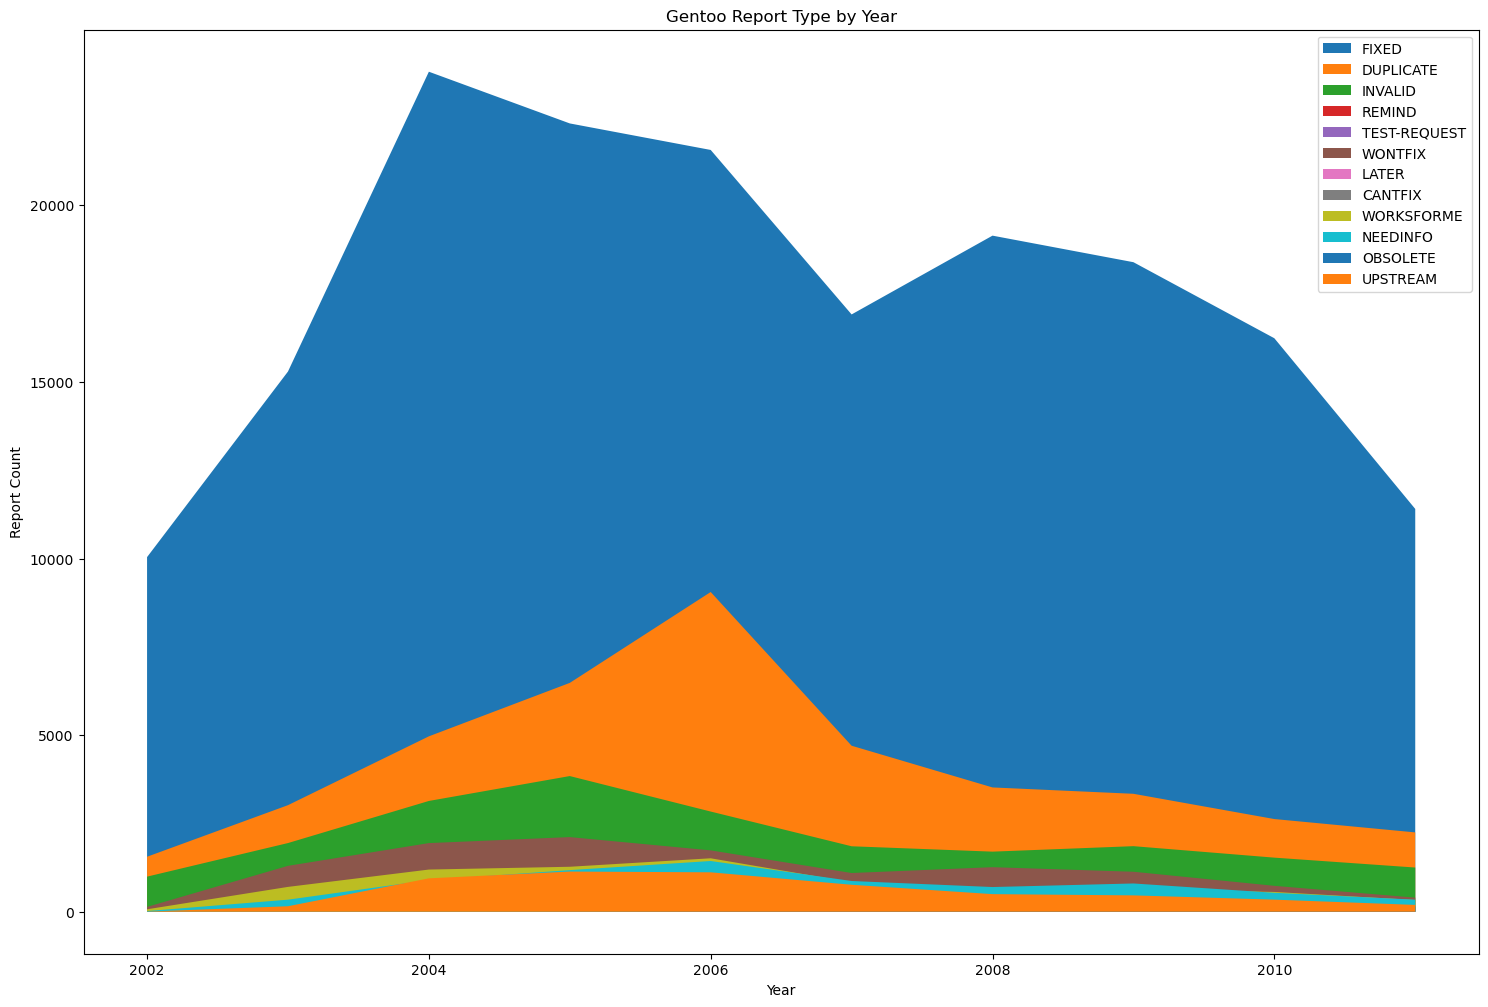

In [4]:
# Figure 2 Block
# X Year, Y Percent, Line = Report Type, 1 Plot per Gentoo, KDE, Suse

def get_each_report_type_count(df):
  report_type_counts = {}

  for resolution in df['resolution'].unique():
    report_type_counts[resolution] = len(df.loc[(df['resolution'] == resolution)])  

  for key in report_type_counts.keys():
    print(f"{key}: {report_type_counts[key]}")
  
# print("GENTOO")
# get_each_report_type_count(data.gentoo)

# print("\nKDE")
# get_each_report_type_count(data.kde)

# print("\nSUSE")
# get_each_report_type_count(data.suse)

def get_report_type_per_year(df):
  report_types_per_year = defaultdict(dict)

  years, counts = get_tickets_per_year(df)

  for year in years:
    sub_frame = df.loc[(df['creation_time'] == year)]   
    for resolution in sub_frame['resolution'].unique():
      report_types_per_year[resolution][year] = len(sub_frame.loc[(sub_frame['resolution'] == resolution)])
  
  return report_types_per_year

gentoo_years_report_type_count = get_report_type_per_year(data.gentoo)
kde_years_report_type_count = get_report_type_per_year(data.kde)
suse_years_report_type_count = get_report_type_per_year(data.suse)

def plot_report_type_per_year(report_type_dict, title):
  fig = plt.figure()
  fig.set_figheight(12)
  fig.set_figwidth(18)
  for resolution in report_type_dict.keys():
    if "nan" not in str(resolution):
      x = report_type_dict[resolution].keys()
      y = []
      for year in x:
        y.append(report_type_dict[resolution][year])
      plt.fill_between(x, y, label=resolution)
  
  plt.xlabel("Year")
  plt.ylabel("Report Count")
  plt.title(title)
  plt.legend()
  plt.plot()    
    

plot_report_type_per_year(gentoo_years_report_type_count, "Gentoo Report Type by Year")

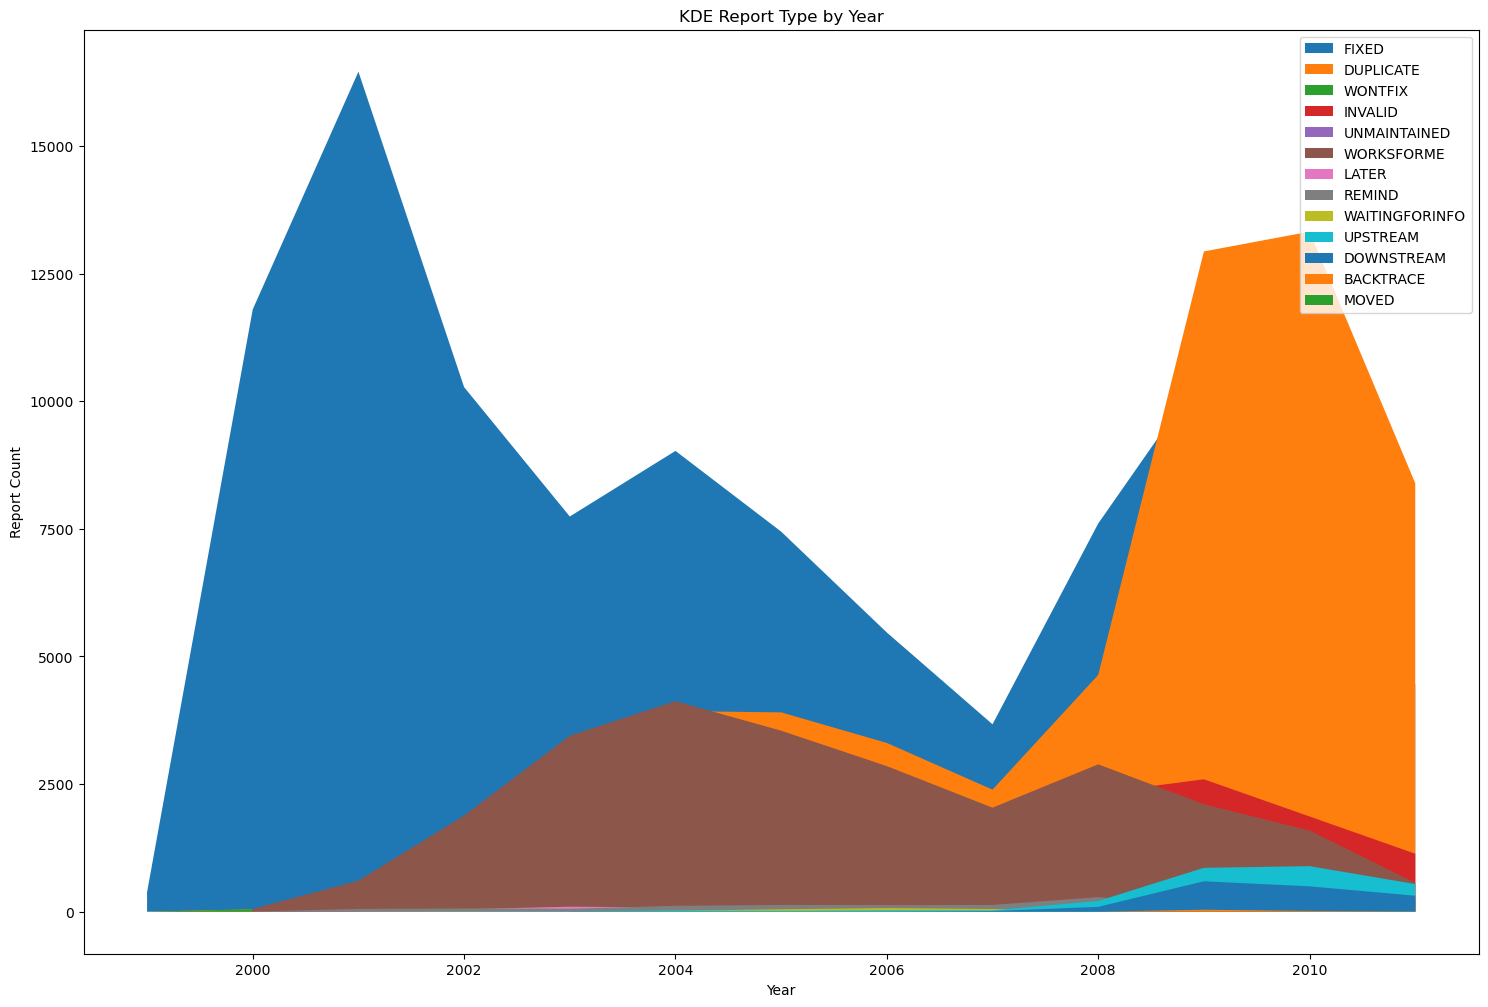

In [5]:
plot_report_type_per_year(kde_years_report_type_count, "KDE Report Type by Year") 

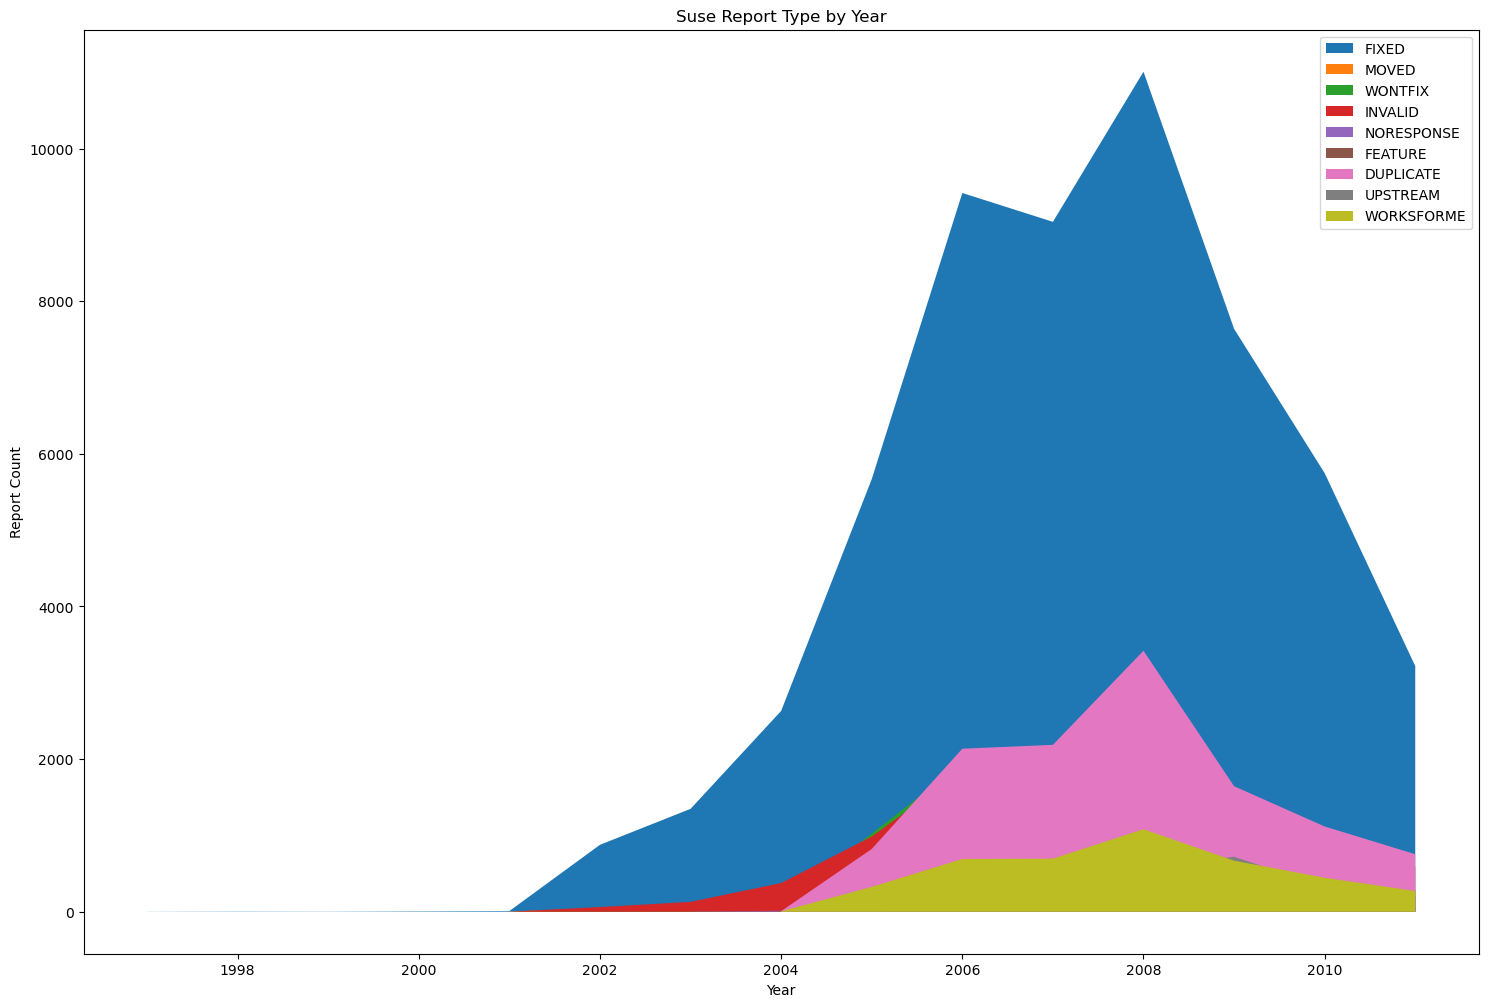

In [6]:
plot_report_type_per_year(suse_years_report_type_count, "Suse Report Type by Year") 

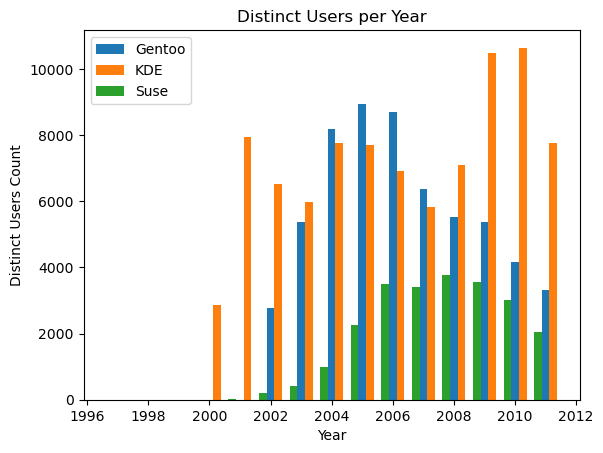

In [7]:
# Figure 3a
# Distincts Users per Year per Repository
# X: Years 
# Y: Number of Distinct Users
# Lines: Repository

def get_distinct_users_per_year(df):
  years, counts = get_tickets_per_year(df)
  user_counts = []
  for year in years:
    sub_frame = df.loc[(df['creation_time'] == year)]   
    user_counts.append(len(sub_frame['creator'].unique()))
  
  return years, user_counts   

def create_distinct_users_per_year(data):
  gentoo_years, gentoo_counts = get_distinct_users_per_year(data.gentoo)
  kde_years, kde_counts = get_distinct_users_per_year(data.kde)
  suse_years, suse_counts = get_distinct_users_per_year(data.suse)

  fig, ax = plt.subplots()
  w = 0.25
  ax.bar(gentoo_years, gentoo_counts, width=w, label='Gentoo')
  ax.bar(kde_years + w, kde_counts, width=w, label='KDE')
  ax.bar(suse_years - w, suse_counts, width=w, label='Suse')  
  ax.set_title('Distinct Users per Year')
  ax.set_xlabel('Year')
  ax.set_ylabel('Distinct Users Count')
  ax.legend()
  plt.show()

create_distinct_users_per_year(data)





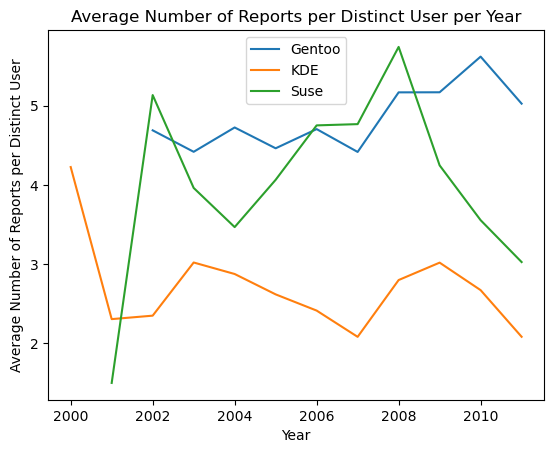

In [8]:
# Figure 3b
# Average number of reports per distinct user per year
# X: Year
# Y: Average number of reports per distinct user
# 1 line per repository

def create_avg_number_of_reports_per_user_plot(data):
  # Drop years before 2000 due to KDE having just one creator
  # Huge outlier due to 300+ avg number blowing up the Y axis
  gentoo_to_drop = data.gentoo[data.gentoo['creation_time'] < 2000].index
  data.gentoo.drop(gentoo_to_drop, inplace=True)
  kde_to_drop = data.kde[data.kde['creation_time'] < 2000].index
  data.kde.drop(kde_to_drop, inplace=True)
  suse_to_drop = data.suse[data.suse['creation_time'] < 2000].index
  data.suse.drop(suse_to_drop, inplace=True)

  gentoo_years, gentoo_user_counts = get_distinct_users_per_year(data.gentoo)
  kde_years, kde_user_counts = get_distinct_users_per_year(data.kde)
  suse_years, suse_user_counts = get_distinct_users_per_year(data.suse)

  tmp, gentoo_report_counts = get_tickets_per_year(data.gentoo)
  tmp, kde_report_counts = get_tickets_per_year(data.kde)
  tmp, suse_report_counts = get_tickets_per_year(data.suse)

  gentoo_avg_reports_per_user = gentoo_report_counts / gentoo_user_counts
  kde_avg_reports_per_user = kde_report_counts / kde_user_counts
  suse_avg_reports_per_user = suse_report_counts / suse_user_counts

  plt.plot(gentoo_years, gentoo_avg_reports_per_user, label='Gentoo')
  plt.plot(kde_years, kde_avg_reports_per_user, label='KDE')
  plt.plot(suse_years, suse_avg_reports_per_user, label='Suse')
  plt.xlabel('Year')
  plt.ylabel('Average Number of Reports per Distinct User')
  plt.title('Average Number of Reports per Distinct User per Year')
  plt.legend()
  plt.plot()

create_avg_number_of_reports_per_user_plot(data)


Calculating Year: 2002 / 2011
Unique Users: 2759
Calculating Year: 2003 / 2011
Unique Users: 5372
Calculating Year: 2004 / 2011
Unique Users: 8195
Calculating Year: 2005 / 2011
Unique Users: 8955
Calculating Year: 2006 / 2011
Unique Users: 8697
Calculating Year: 2007 / 2011
Unique Users: 6384
Calculating Year: 2008 / 2011
Unique Users: 5530
Calculating Year: 2009 / 2011
Unique Users: 5366
Calculating Year: 2010 / 2011
Unique Users: 4171
Calculating Year: 2011 / 2011
Unique Users: 3327


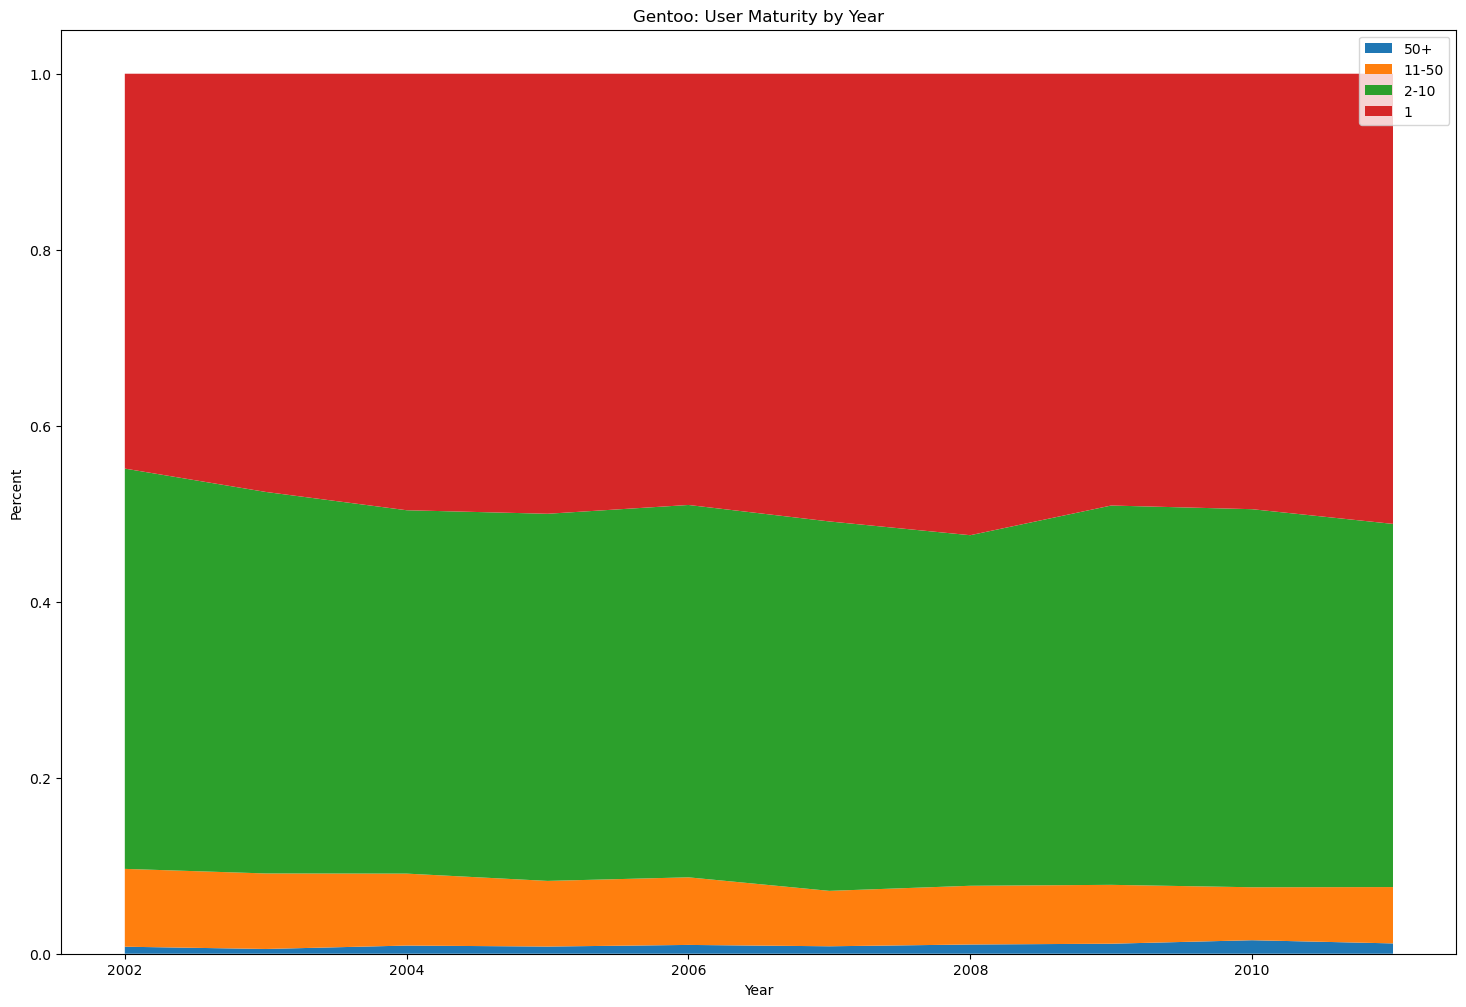

In [34]:
# Figure 4
# User Maturity By Year
# X: Year
# Y: Percent 
# Categories: 50+ Reports, 11-50 Reports, 2-10 Reports, 1 Report
# One plot per repository

# User Maturity Category Indices
# 0 => 50+ Reports
# 1 => 11-50 Reports
# 2 => 2-10 Reports
# 3 => 1 Report

def get_user_count_by_ticket_range(df):
  maturity_counts = np.array([0,0,0,0])
  user_list = df['creator'].unique()
  print(f"Unique Users: {len(user_list)}")
  for user in user_list:
    times_user_appears = len(df.loc[(df['creator'] == user)])    
    if times_user_appears >= 50:    
      maturity_counts[0] += 1
    elif times_user_appears >= 11 and times_user_appears < 50:
      maturity_counts[1] += 1
    elif times_user_appears >= 2 and times_user_appears < 11:
      maturity_counts[2] += 1
    elif times_user_appears == 1:
      maturity_counts[3] += 1  
  
  maturity_counts = maturity_counts / len(user_list)

  return maturity_counts

def get_user_maturity(df):
  years, tmp = get_tickets_per_year(df)
  maturity_counts = []
  for year in years:
    print(f"Calculating Year: {year} / {years[-1]}")
    sub_frame = df.loc[(df['creation_time'] == year)]   
    maturity_counts.append(get_user_count_by_ticket_range(sub_frame))
    
  return years, np.array(maturity_counts)

def plot_user_maturity(df, df_name):
  years, maturity_counts = get_user_maturity(df)  
  fig = plt.figure()
  fig.set_figheight(12)
  fig.set_figwidth(18)

  category_strs = ["50+", "11-50", "2-10", "1"]
  y = []
  for category in range(0,4):
    x = years
    y.append([maturity_counts[i][category] for i in range(len(years))])
  plt.stackplot(x, y[0], y[1], y[2], y[3], labels=category_strs)

  plt.xlabel("Year")
  plt.ylabel("Percent")
  plt.title(f"{df_name}: User Maturity by Year")
  plt.legend()
  plt.plot()    

plot_user_maturity(data.gentoo, "Gentoo")




Calculating Year: 2000 / 2011
Unique Users: 2850
Calculating Year: 2001 / 2011
Unique Users: 7946
Calculating Year: 2002 / 2011
Unique Users: 6527
Calculating Year: 2003 / 2011
Unique Users: 5986
Calculating Year: 2004 / 2011
Unique Users: 7758
Calculating Year: 2005 / 2011
Unique Users: 7698
Calculating Year: 2006 / 2011
Unique Users: 6920
Calculating Year: 2007 / 2011
Unique Users: 5825
Calculating Year: 2008 / 2011
Unique Users: 7111
Calculating Year: 2009 / 2011
Unique Users: 10478
Calculating Year: 2010 / 2011
Unique Users: 10644
Calculating Year: 2011 / 2011
Unique Users: 7772


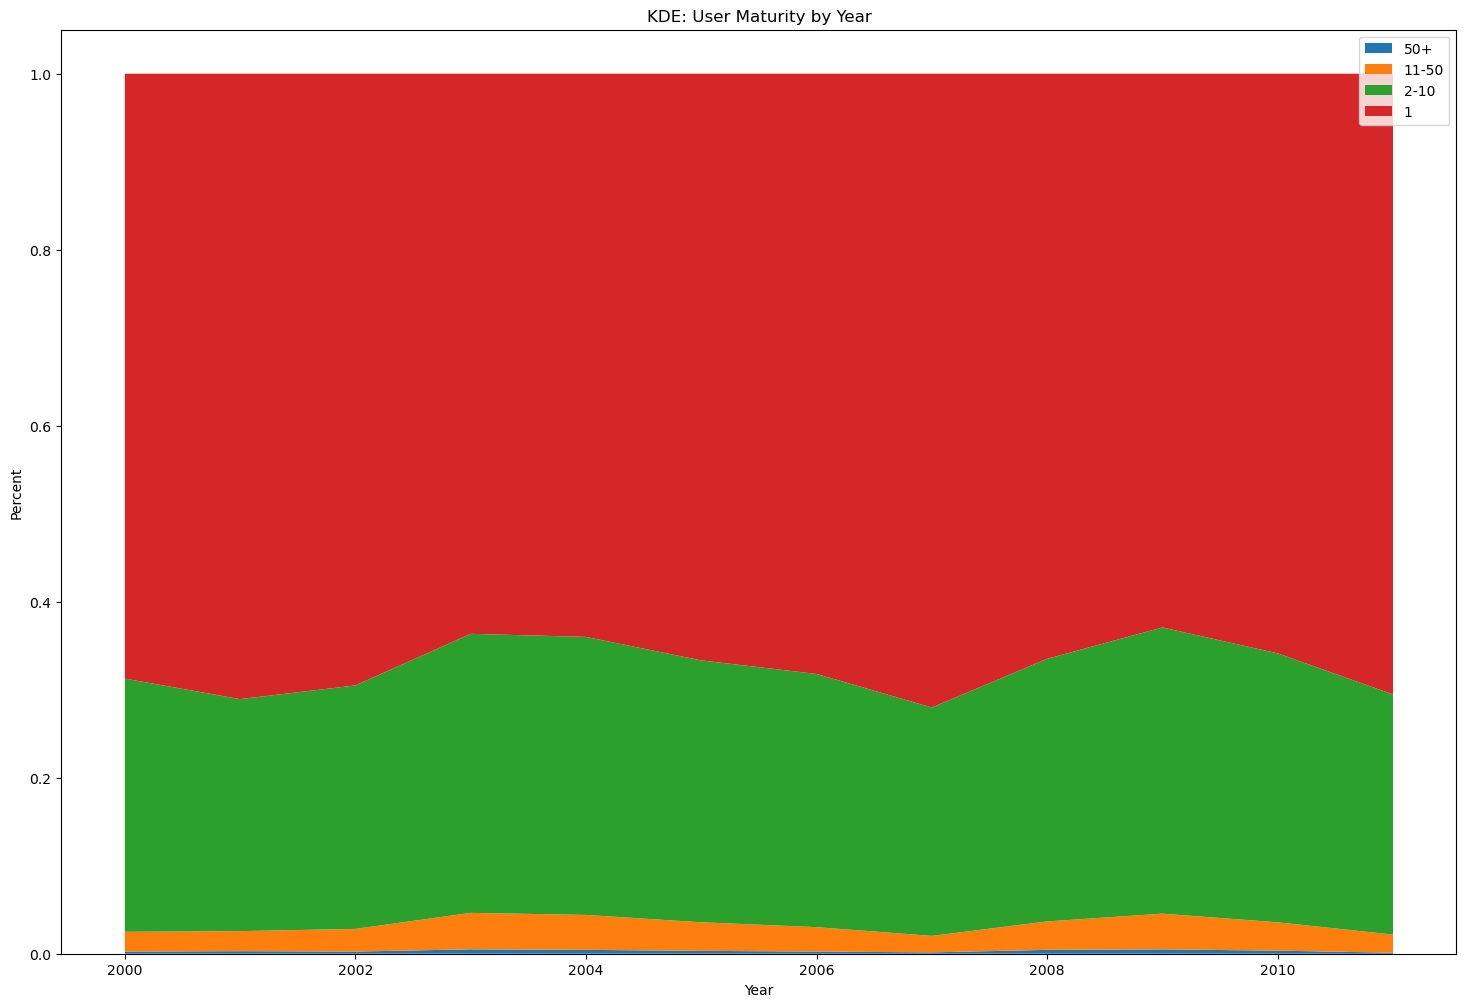

In [35]:
plot_user_maturity(data.kde, "KDE")

Calculating Year: 2001 / 2011
Unique Users: 8
Calculating Year: 2002 / 2011
Unique Users: 196
Calculating Year: 2003 / 2011
Unique Users: 406
Calculating Year: 2004 / 2011
Unique Users: 986
Calculating Year: 2005 / 2011
Unique Users: 2273
Calculating Year: 2006 / 2011
Unique Users: 3498
Calculating Year: 2007 / 2011
Unique Users: 3396
Calculating Year: 2008 / 2011
Unique Users: 3758
Calculating Year: 2009 / 2011
Unique Users: 3567
Calculating Year: 2010 / 2011
Unique Users: 3002
Calculating Year: 2011 / 2011
Unique Users: 2048


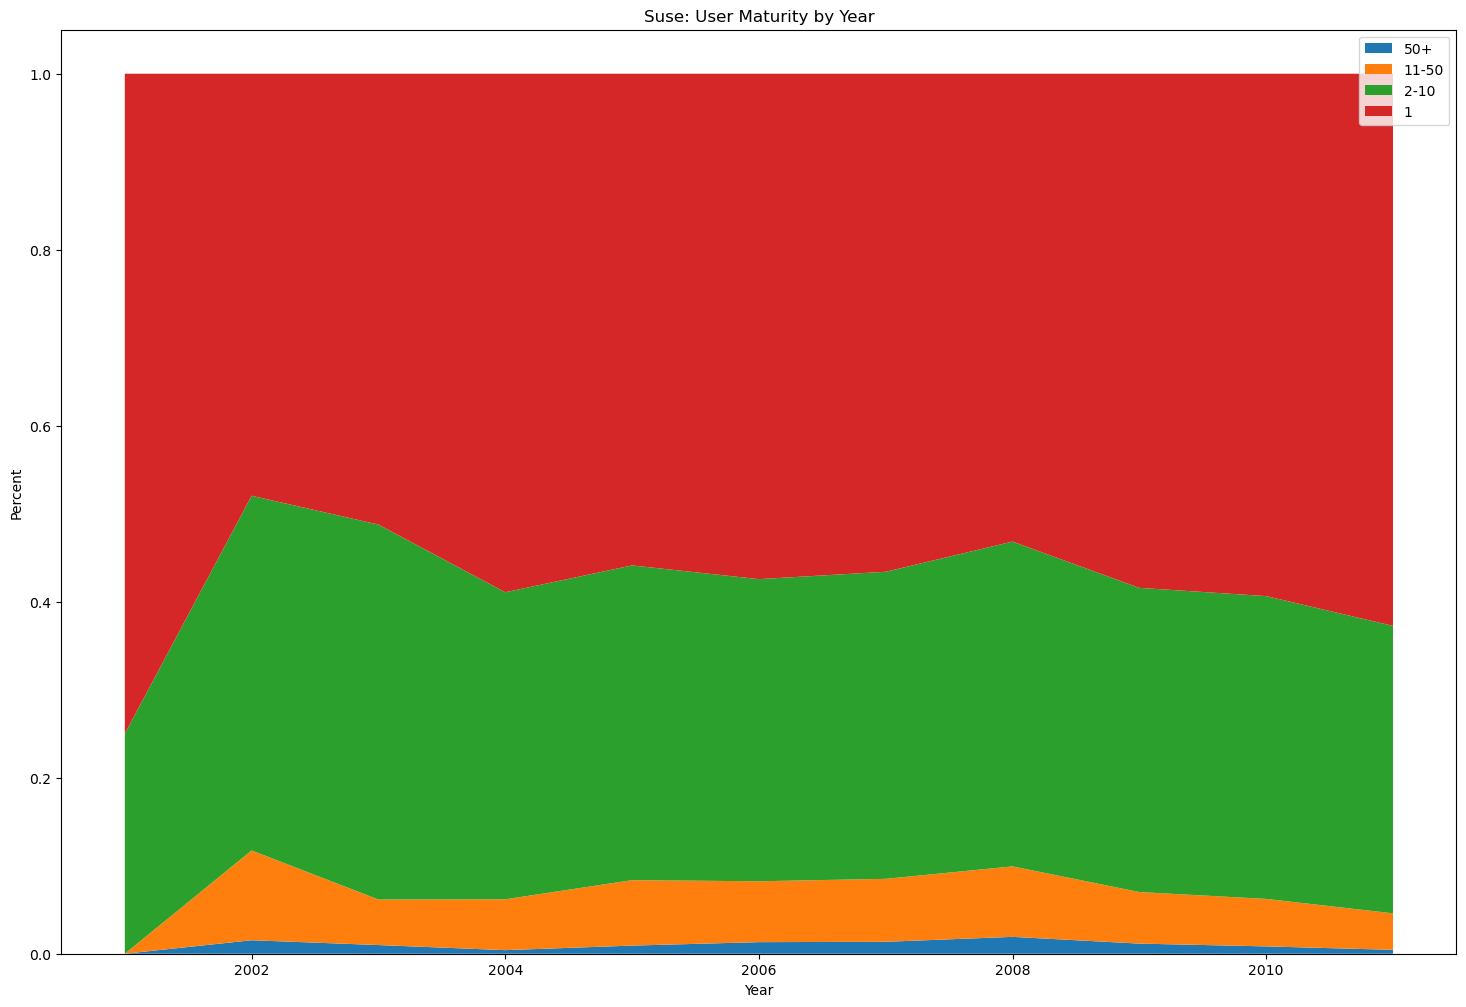

In [36]:
plot_user_maturity(data.suse, "Suse")